# Week 3 DBSCAN Notebook - Density-Based Anomaly Discovery

This notebook is focused on DBSCAN as a density-based method for Week 3:
1. Tune DBSCAN to separate dense normal regions from sparse anomaly regions
2. Cluster known anomalies to inspect potential 4-type structure
3. Build a DBSCAN-derived anomaly score for third batch and save submission-ready files

## Practical Plan

- Use combined labeled data from training + first + second batch for robust density estimation.
- Build user features with existing feature pipeline.
- Standardize features, then use k-distance diagnostics to choose a DBSCAN eps range.
- Grid-search eps and min_samples using a binary objective: anomalies should fall into noise/small sparse groups while normals stay in dense clusters.
- Fit final DBSCAN on all train users, then transfer to test users using nearest-core assignment and distance-to-core scoring.
- Save DBSCAN-only scores and optional blended scores.

In [22]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score

from feature_pipeline import (
    combine_labeled_data,
    load_data,
    compute_item_stats,
    build_features,
    get_feature_columns,
)

np.random.seed(42)

In [23]:
# 1) Load combined labeled training and third batch test
combined_path = combine_labeled_data(
    'data/training_batch_with_labels.npz',
    'data/first_batch_with_labels.npz',
    'data/second_batch_with_labels.npz',
    output_path='data/combined_all_labeled.npz'
)

XX_train, yy, XX_test = load_data(combined_path, test_path='data/third_batch.npz')
print('Train interactions:', XX_train.shape)
print('Train labels:', yy.shape)
print('Test interactions:', XX_test.shape)
print('Train anomaly rate:', yy['label'].mean())

Combined 3 files → data/combined_all_labeled.npz
  3060 users (260 anomalous, 2800 normal), 479433 interactions
Train interactions: (479433, 3)
Train labels: (3060, 2)
Test interactions: (256072, 3)
Train anomaly rate: 0.08496732026143791


In [24]:
# 2) Build features
item_stats = compute_item_stats(XX_train, yy_train=yy)
train_feats = build_features(XX_train, item_stats)
test_feats = build_features(XX_test, item_stats)

train_df = train_feats.merge(yy, on='user', how='left')
feature_cols = get_feature_columns(train_df)

X_train = train_df[feature_cols].fillna(0).values
y_train = train_df['label'].values.astype(int)
X_test = test_feats[feature_cols].fillna(0).values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Feature count:', len(feature_cols))
print('Train matrix:', X_train_s.shape, 'Test matrix:', X_test_s.shape)

Feature count: 60
Train matrix: (3060, 60) Test matrix: (1625, 60)


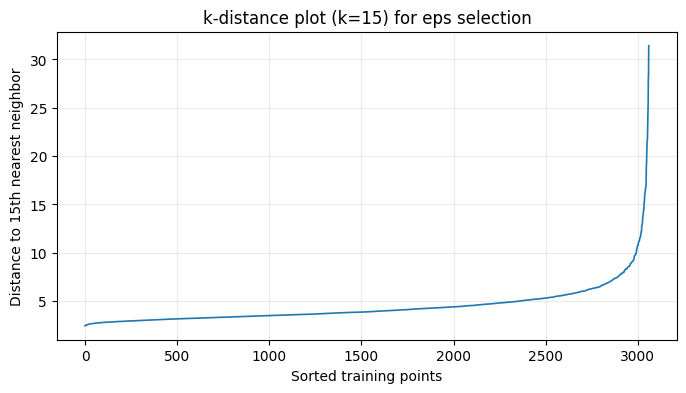

Suggested eps candidates from quantiles:
  q=0.80: eps=5.2015
  q=0.85: eps=5.6204
  q=0.90: eps=6.2985
  q=0.93: eps=6.9690
  q=0.95: eps=7.7667
  q=0.97: eps=9.0440


In [25]:
# 3) k-distance diagnostic to pick DBSCAN eps candidates
k_for_plot = 15
nn = NearestNeighbors(n_neighbors=k_for_plot, metric='euclidean')
nn.fit(X_train_s)
distances, _ = nn.kneighbors(X_train_s)
kdist = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(kdist, linewidth=1.2)
plt.title(f'k-distance plot (k={k_for_plot}) for eps selection')
plt.xlabel('Sorted training points')
plt.ylabel(f'Distance to {k_for_plot}th nearest neighbor')
plt.grid(alpha=0.25)
plt.show()

eps_candidates = np.quantile(kdist, [0.80, 0.85, 0.90, 0.93, 0.95, 0.97])
print('Suggested eps candidates from quantiles:')
for q, e in zip([0.80, 0.85, 0.90, 0.93, 0.95, 0.97], eps_candidates):
    print(f'  q={q:.2f}: eps={e:.4f}')

In [26]:
# 4) Parameter search with a binary objective
# Goal: anomalies should be mostly noise, normals should be mostly clustered.
def evaluate_dbscan_binary(labels, y_true):
    is_noise = (labels == -1).astype(int)
    anom_noise_recall = ((is_noise == 1) & (y_true == 1)).sum() / max((y_true == 1).sum(), 1)
    norm_cluster_rate = ((is_noise == 0) & (y_true == 0)).sum() / max((y_true == 0).sum(), 1)
    noise_rate = is_noise.mean()

    # Penalize degenerate solutions where almost everything is noise.
    score = 0.65 * anom_noise_recall + 0.35 * norm_cluster_rate
    if noise_rate > 0.70:
        score -= 0.20 * (noise_rate - 0.70)
    return {
        'score': score,
        'anom_noise_recall': anom_noise_recall,
        'norm_cluster_rate': norm_cluster_rate,
        'noise_rate': noise_rate,
    }

records = []
min_samples_grid = [8, 12, 15, 20, 25, 30]

for eps in eps_candidates:
    for min_samples in min_samples_grid:
        db = DBSCAN(eps=float(eps), min_samples=int(min_samples), metric='euclidean')
        labels = db.fit_predict(X_train_s)

        m = evaluate_dbscan_binary(labels, y_train)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        records.append({
            'eps': float(eps),
            'min_samples': int(min_samples),
            'n_clusters': int(n_clusters),
            **m
        })

grid_df = pd.DataFrame(records).sort_values('score', ascending=False).reset_index(drop=True)
grid_df.head(15)

,eps,min_samples,n_clusters,score,anom_noise_recall,norm_cluster_rate,noise_rate
0,5.201543,30,1,0.423250,0.176923,0.880714,0.124183
1,5.201543,20,1,0.411375,0.146154,0.903929,0.100327
2,5.201543,25,2,0.408875,0.150000,0.889643,0.113725
3,5.201543,15,1,0.400375,0.126923,0.908214,0.094771
4,5.201543,8,1,0.398750,0.119231,0.917857,0.085294
5,5.620365,30,1,0.397875,0.119231,0.915357,0.087582
6,5.201543,12,1,0.396500,0.119231,0.911429,0.091176
7,5.620365,25,1,0.394125,0.111538,0.918929,0.083660
8,5.620365,20,1,0.393250,0.107692,0.923571,0.079085
9,5.620365,15,1,0.386375,0.096154,0.925357,0.076471


In [27]:
# 5) Fit final DBSCAN from best params
best = grid_df.iloc[0]
best_eps = float(best['eps'])
best_min_samples = int(best['min_samples'])

db_final = DBSCAN(eps=best_eps, min_samples=best_min_samples, metric='euclidean')
train_labels = db_final.fit_predict(X_train_s)

print('Best params:', {'eps': best_eps, 'min_samples': best_min_samples})
print('Metrics:', {
    'score': float(best['score']),
    'anom_noise_recall': float(best['anom_noise_recall']),
    'norm_cluster_rate': float(best['norm_cluster_rate']),
    'noise_rate': float(best['noise_rate']),
    'n_clusters': int(best['n_clusters'])
})

train_out = pd.DataFrame({
    'user': train_df['user'].values,
    'label': y_train,
    'dbscan_cluster': train_labels
})
train_out.head()

Best params: {'eps': 5.201542872583988, 'min_samples': 30}
Metrics: {'score': 0.42324999999999996, 'anom_noise_recall': 0.17692307692307693, 'norm_cluster_rate': 0.8807142857142857, 'noise_rate': 0.12418300653594772, 'n_clusters': 1}


,user,label,dbscan_cluster
0,100,0,0
1,101,0,0
2,102,0,0
3,103,0,0
4,104,0,0


In [28]:
# 6) Cluster profiling on anomalous users
anom_mask = (train_out['label'] == 1)
anom_clusters = train_out.loc[anom_mask, 'dbscan_cluster']

print('Anomaly cluster counts (including noise = -1):')
print(anom_clusters.value_counts().sort_index())

profile_df = train_feats.copy()
profile_df = profile_df.merge(train_out[['user', 'label', 'dbscan_cluster']], on='user', how='left')

# Focus on top features by simple anomaly separation in training
num_cols = [c for c in feature_cols if c in profile_df.columns]
sep = {}
for c in num_cols:
    a = profile_df.loc[profile_df['label'] == 1, c].values
    n = profile_df.loc[profile_df['label'] == 0, c].values
    sep[c] = abs(np.nanmean(a) - np.nanmean(n))

top_feats = sorted(sep, key=sep.get, reverse=True)[:12]
cluster_profile = profile_df[profile_df['label'] == 1].groupby('dbscan_cluster')[top_feats].mean()
cluster_profile

Anomaly cluster counts (including noise = -1):
-1     46
 0    214
Name: dbscan_cluster, dtype: int64


,rating_count,unique_items_rated,avg_item_popularity,std_item_popularity,rating_kurt,extreme_mid_ratio,deviation_range,second_half_rating_var,first_half_rating_var,count_x_pop,min_deviation,rating_median
dbscan_cluster,,,,,,,,,,,,
-1,64.782609,64.782609,988.408310,493.200232,-1.084995,0.654565,4.522811,1.782141,1.611233,9.538862,-2.926174,2.760870
0,150.107477,150.107477,893.994893,490.951454,-0.483731,0.844195,5.054742,1.596097,1.597356,11.452311,-2.870046,3.198598


In [29]:
# 7) Create DBSCAN score for train/test via nearest-core distance
# DBSCAN has no native predict in sklearn. We use nearest core sample distance.
core_idx = getattr(db_final, 'core_sample_indices_', None)

if core_idx is None or len(core_idx) == 0:
    raise RuntimeError('No core samples found. Try larger eps or smaller min_samples.')

core_points = X_train_s[core_idx]
core_nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
core_nn.fit(core_points)

d_train_core, _ = core_nn.kneighbors(X_train_s)
d_test_core, _ = core_nn.kneighbors(X_test_s)

# Noise indicator from train fit
train_noise = (train_labels == -1).astype(float)

# Distance-based smooth score
dist_scale = np.median(d_train_core) + 1e-9
score_train_dist = 1.0 - np.exp(-d_train_core.ravel() / dist_scale)
score_test_dist = 1.0 - np.exp(-d_test_core.ravel() / dist_scale)

# Hybrid train score combines explicit DBSCAN noise and distance smoothness
score_train_dbscan = 0.70 * train_noise + 0.30 * score_train_dist
score_test_dbscan = score_test_dist.copy()

# Normalize with train fit
mm = MinMaxScaler()
score_train_dbscan = mm.fit_transform(score_train_dbscan.reshape(-1, 1)).ravel()
score_test_dbscan = mm.transform(score_test_dbscan.reshape(-1, 1)).ravel()

print('Train DBSCAN score AUC:', roc_auc_score(y_train, score_train_dbscan))

best_f1 = -1
best_thr = 0.5
for t in np.linspace(0.01, 0.99, 400):
    f = f1_score(y_train, (score_train_dbscan >= t).astype(int), zero_division=0)
    if f > best_f1:
        best_f1 = f
        best_thr = float(t)

print('Train DBSCAN best F1:', best_f1, 'at threshold:', best_thr)

Train DBSCAN score AUC: 0.5509986263736263
Train DBSCAN best F1: 0.1675098369870714 at threshold: 0.01


In [ ]:
# 8) Final submission cell (simple, clean, single output)
# Run this after Cell 7. It creates ONE final file for upload.

import os
import numpy as np


def norm01(x):
    x = np.asarray(x, dtype=float).ravel()
    lo, hi = x.min(), x.max()
    if hi - lo < 1e-12:
        return np.zeros_like(x)
    return (x - lo) / (hi - lo)


def load_first_existing(paths, label):
    for p in paths:
        if os.path.exists(p):
            arr = np.load(p)["predictions"].ravel()
            print(f"Loaded {label}: {p}")
            return arr, p
    raise FileNotFoundError(f"Could not find {label} in: {paths}")


# 1) Load supervised anchor score (best known branch)
supervised_score, supervised_path = load_first_existing(
    [
        "submission_week3_supervised_heavy.npz",
        "submission_week3_tuned_final.npz",
        "submission_week3_best_single.npz",
    ],
    "supervised score",
)

# 2) Load DBSCAN novelty score
dbscan_score, dbscan_path = load_first_existing(
    [
        "submission_week3_dbscan_only.npz",
        "submission_try3_dbscan_only.npz",
        "submission_week3_supervised60_dbscan40.npz",
    ],
    "dbscan score",
)

supervised_score = norm01(supervised_score)
dbscan_score = norm01(dbscan_score)

if len(supervised_score) != len(dbscan_score):
    raise ValueError(
        f"Length mismatch: supervised={len(supervised_score)} vs dbscan={len(dbscan_score)}"
    )

# 3) Final blend (proven strong region on your leaderboard)
alpha = 0.70  # 70% supervised + 30% DBSCAN
final_score = norm01(alpha * supervised_score + (1 - alpha) * dbscan_score)

# 4) Save final submission file
output_file = "submission_final.npz"
np.savez(output_file, predictions=final_score)

print("\nSaved final submission:", output_file)
print("Blend:", f"{alpha:.2f} supervised + {1-alpha:.2f} DBSCAN")
print("Sources:")
print("  supervised:", supervised_path)
print("  dbscan:", dbscan_path)

Loaded best_single from: submission_week3_best_single.npz
Loaded supervised_heavy from: submission_week3_supervised_heavy.npz
Loaded dbscan_proxy from: submission_week3_dbscan_only.npz
Saved: submission_final_try1_best_single_anchor.npz
Saved: submission_final_try2_best85_sup15.npz
Saved: submission_final_try3_best90_db10.npz
Saved: submission_final_try4_best80_sup10_db10.npz
Saved: submission_final_try5_rank85_db15.npz

Sources used:
  best_single: submission_week3_best_single.npz
  supervised_heavy: submission_week3_supervised_heavy.npz
  dbscan_proxy: submission_week3_dbscan_only.npz

Generated 5 final submissions based on strongest prior anchors.
